# Credit Card Fraud Detection
**Colin Ng**

A simple project covering ETL, exploratory analysis, outlier detection, and fraud prediction.

`V1`–`V28` are already PCA-transformed for privacy. `Time` is elapsed seconds, `Amount` is transaction value, and `Class` is the label: 0 = legitimate, 1 = fraud. Negative PCA values are valid, and PCA does not guarantee normal distributions. We cannot interpret the components as original customer or merchant attributes.

The dataset contains about two days of transactions from 2013, so these results are a historical benchmark.


## 1. Load and check the data
This is the **extract** step. Need to load dataset before cleaning. Checking the size, missing values, duplicates, and fraud rate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             precision_score, recall_score, f1_score, confusion_matrix)
from xgboost import XGBClassifier

# Load the transactions into a DataFrame.
df = pd.read_csv('creditcard.csv')
print('Shape:', df.shape)
print('Missing values:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Fraud rate:', round(df['Class'].mean() * 100, 3), '%')
df.head()

Shape: (152629, 31)
Missing values: 23
Duplicate rows: 591
Fraud rate: 0.216 %


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## 2. Clean and save the data
This is the **transforming and loading** step. Checking that the expected columns and values are present, then remove exact duplicates and sort by time. Save the cleaned CSV for iteration.

I am keeping the first row as a project assumption since without transaction IDs, identical rows could still represent separate transactions. I keep unusual values because they may be important fraud signals. If missing or invalid values exist we investigate.

In [3]:
expected = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
assert set(df.columns) == set(expected), 'Unexpected columns'

# Treat infinity as missing, then remove incomplete transactions.
df = df.replace([np.inf, -np.inf], np.nan)
rows_before = len(df)
df = df.dropna(subset=expected).copy()
print('Incomplete rows removed:', rows_before - len(df))

assert df['Class'].isin([0, 1]).all(), 'Unexpected labels'
assert (df[['Time', 'Amount']] >= 0).all().all(), 'Negative time or amount'

df = df.drop_duplicates().sort_values('Time').reset_index(drop=True)
df.to_csv('creditcard_clean.csv', index=False)
print('Cleaned shape:', df.shape)

Incomplete rows removed: 1
Cleaned shape: (152037, 31)


## 3. Split before analysis and modeling
Using transactions for training, the next portion for validation, and the latest portion for testing—roughly 60% / 20% / 20%. This way equal timestamps stay together.

Validation is used to choose score thresholds. Test data is reserved for final evaluation. We preserve the natural fraud imbalance instead of balancing validation or test data.

In [4]:
first_cut = df['Time'].iloc[int(len(df) * 0.6)]
second_cut = df['Time'].iloc[int(len(df) * 0.8)]

train = df[df['Time'] < first_cut].copy()
valid = df[(df['Time'] >= first_cut) & (df['Time'] < second_cut)].copy()
test = df[df['Time'] >= second_cut].copy()

for name, data in [('Train', train), ('Validation', valid), ('Test', test)]:
    assert data['Class'].nunique() == 2, 'Each split needs both labels'
    print(f'{name}: {len(data):,} transactions, {data["Class"].sum()} frauds')

# X contains inputs; y contains the fraud label we want to predict.
X_train, y_train = train.drop(columns='Class'), train['Class']
X_valid, y_valid = valid.drop(columns='Class'), valid['Class']
X_test, y_test = test.drop(columns='Class'), test['Class']

Train: 91,221 transactions, 211.0 frauds
Validation: 30,408 transactions, 33.0 frauds
Test: 30,408 transactions, 68.0 frauds


## 4. Explore the training data
Use training data to examine class imbalance and transaction amounts. A logarithmic count axis in the chart makes the small fraud class visible; `log1p(Amount)` compresses large amounts for the histogram and handles zero values.

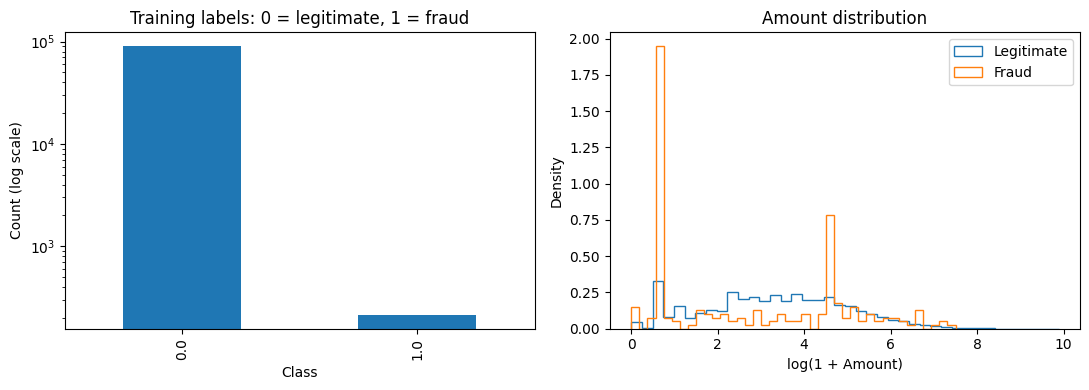

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,91010.0,99.024256,268.345804,0.0,7.68,27.00,89.99,19656.53
1.0,211.0,106.714360,242.747461,0.0,1.00,7.58,99.99,1809.68


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train['Class'].value_counts().sort_index().plot.bar(ax=axes[0], logy=True)
axes[0].set(title='Training labels: 0 = legitimate, 1 = fraud', ylabel='Count (log scale)')

for label, name in [(0, 'Legitimate'), (1, 'Fraud')]:
    amounts = train.loc[train['Class'] == label, 'Amount']
    axes[1].hist(np.log1p(amounts), bins=40, density=True, histtype='step', label=name)
axes[1].set(title='Amount distribution', xlabel='log(1 + Amount)', ylabel='Density')
axes[1].legend()
plt.tight_layout()
plt.show()

train.groupby('Class')['Amount'].describe()

## 5. Find outliers with IQR


**Q1 − 1.5 × IQR** and **Q3 + 1.5 × IQR**, where IQR = Q3 − Q1.

Learning the bounds from training data only. Exclude `Time` because a later timestamp is not inherently suspicious or an outlier. Outliers are flags for investigation, not rows to delete or proof of fraud. Checking many features can flag a large share of legitimate transactions.

In [6]:
outlier_columns = [f'V{i}' for i in range(1, 29)] + ['Amount']
q1 = train[outlier_columns].quantile(0.25)
q3 = train[outlier_columns].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Compare every training value with its feature's bounds.
iqr_flags = (train[outlier_columns] < lower) | (train[outlier_columns] > upper)
print('Amount upper bound:', round(upper['Amount'], 2))
print('Most frequently flagged features:')
print(iqr_flags.sum().sort_values(ascending=False).head(10))
pd.crosstab(train['Class'], iqr_flags.any(axis=1), colnames=['Any IQR flag'])

Amount upper bound: 213.56
Most frequently flagged features:
V28       17034
V27       13402
Amount     9807
V20        9441
V8         8067
V23        7765
V6         7469
V21        5917
V5         5569
V12        5441
dtype: int64


Any IQR flag,False,True
Class,,
0.0,44895,46115
1.0,7,204


## 6. Find unusual combinations with Isolation Forest
IQR checks one feature at a time where as Isolation Forests can identify unusual combinations of values, without using fraud labels.

Fit on training data. Negating its scores so larger values mean more unusual transactions. Use the training 99th percentile as a cutoff

In [7]:
isolation = IsolationForest(n_estimators=100, random_state=42, n_jobs=2)
isolation.fit(train[outlier_columns])
train_scores = -isolation.score_samples(train[outlier_columns])
anomaly_cutoff = np.quantile(train_scores, 0.99)

valid_scores = -isolation.score_samples(valid[outlier_columns])
print('Validation anomaly average precision:', round(average_precision_score(y_valid, valid_scores), 3))
pd.crosstab(y_valid, valid_scores >= anomaly_cutoff, colnames=['Anomaly flag'])

Validation anomaly average precision: 0.054


Anomaly flag,False,True
Class,,
0.0,30170,205
1.0,22,11


## 7. Train logistic regression and XGBoost
Keeping all training observations. A weighted logistic regression gives the rare fraud class more influence; XGBoost is an unweighted tree-model comparison.


In [8]:
models = {
    'Logistic regression': make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
    ),
    'XGBoost': XGBClassifier(
        n_estimators=250, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, tree_method='hist',
        eval_metric='aucpr', random_state=42, n_jobs=2
    )
}

validation_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    # Column 1 contains scores for the fraud class.
    validation_scores[name] = model.predict_proba(X_valid)[:, 1]
    ap = average_precision_score(y_valid, validation_scores[name])
    print(f'{name}: validation average precision = {ap:.3f}')

Logistic regression: validation average precision = 0.523
XGBoost: validation average precision = 0.647


## 8. Choosing thresholds using validation
A score threshold determines which transactions trigger alerts. Choosing each model's threshold to maximize validation **F2**, which emphasizes recall more than precision. A business would choose thresholds using costs and review capacity.

The precision–recall function returns one extra endpoint without a threshold, so we remove it before calculating F2. Selecting the primary model using validation average precision.

In [9]:
thresholds = {}
for name, scores in validation_scores.items():
    precision, recall, cutoffs = precision_recall_curve(y_valid, scores)
    precision, recall = precision[:-1], recall[:-1]
    # F2 = 5PR / (4P + R); a tiny denominator floor avoids division by zero.
    f2 = 5 * precision * recall / np.maximum(4 * precision + recall, 1e-12)
    thresholds[name] = cutoffs[np.argmax(f2)]
    print(f'{name}: selected threshold = {thresholds[name]:.6f}')

best_model = max(validation_scores, key=lambda name:
                 average_precision_score(y_valid, validation_scores[name]))
print('Model selected on validation:', best_model)

Logistic regression: selected threshold = 0.990231
XGBoost: selected threshold = 0.142637
Model selected on validation: XGBoost


## 9. Evaluate on the final test set
Using the trained models and validation thresholds. Report ranking quality, precision, recall, and the actual numbers of frauds caught, missed frauds, and false alerts.

- **Average precision:** how well scores rank fraud above legitimate transactions across thresholds.
- **Precision:** of the flagged transactions, how many were fraud?
- **Recall:** of all frauds, how many were caught?
- **F1:** an equal-weight balance between precision and recall.


In [10]:
results = []
for name, model in models.items():
    scores = model.predict_proba(X_test)[:, 1]
    alerts = scores >= thresholds[name]
    tn, fp, fn, tp = confusion_matrix(y_test, alerts, labels=[0, 1]).ravel()
    results.append({
        'Model': name,
        'Average precision': average_precision_score(y_test, scores),
        'Precision': precision_score(y_test, alerts, zero_division=0),
        'Recall': recall_score(y_test, alerts, zero_division=0),
        'F1': f1_score(y_test, alerts, zero_division=0),
        'Frauds caught': tp, 'Frauds missed': fn, 'False alerts': fp
    })

test_table = pd.DataFrame(results).set_index('Model')
print(f'Always-legitimate accuracy: {1 - y_test.mean():.2%}, with zero fraud recall.')
test_table.round(3)

Always-legitimate accuracy: 99.78%, with zero fraud recall.


,Average precision,Precision,Recall,F1,Frauds caught,Frauds missed,False alerts
Model,,,,,,,
Logistic regression,0.737,0.659,0.794,0.720,54,14,28
XGBoost,0.830,0.857,0.794,0.824,54,14,9


## 10. Inspect the most unusual test transactions
Using the same training-fitted outlier rules on the test data. This final table helps investigate transactions by showing their known label, amount, IQR flag count, and anomaly score. The labels are used for retrospective comparison, not for calculating anomaly scores.

In [11]:
test_iqr = (test[outlier_columns] < lower) | (test[outlier_columns] > upper)
outliers = test[['Time', 'Amount', 'Class']].copy()
outliers['IQR flag count'] = test_iqr.sum(axis=1)
outliers['Anomaly score'] = -isolation.score_samples(test[outlier_columns])
outliers['Anomaly flag'] = outliers['Anomaly score'] >= anomaly_cutoff

print('Test anomaly / label overlap:')
print(pd.crosstab(outliers['Class'], outliers['Anomaly flag']))
outliers.sort_values('Anomaly score', ascending=False).head(10)

Test anomaly / label overlap:
Anomaly flag  False  True 
Class                     
0.0           30119    221
1.0              25     43


,Time,Amount,Class,IQR flag count,Anomaly score,Anomaly flag
150704,95286,18910.00,0.0,24,0.786027,True
150418,94362,1.00,1.0,22,0.757938,True
130987,79617,1593.37,0.0,20,0.751250,True
151633,97121,8.64,1.0,21,0.749675,True
151704,97235,9.82,1.0,23,0.748964,True
150419,94364,1.00,1.0,22,0.747480,True
150097,93879,30.31,1.0,21,0.743315,True
150871,95559,1.63,1.0,22,0.742850,True
144538,86624,2018.09,0.0,20,0.738088,True
150927,95628,1.63,1.0,21,0.736740,True


## 11. Conclusion
XGBoost performed better on the final test set overall, same frauds caught and frauds missed but less false alerts.

After validating and cleaning the data, I found that statistical outliers were not reliable indicators of fraud on their own. IQR flagged many legitimate transactions, and Isolation Forest detected only a minority of test frauds. Supervised models performed substantially better. XGBoost achieved the strongest test ranking and recall, detecting 54 of 68 frauds with 9 false alerts, while weighted logistic regression offered lower precision and more false alerts. The preferred model would depend on the acceptable tradeoff between missed fraud and review workload.